In [3]:
pip install pdfplumber

  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached pdfminer_six-20251230-py3-none-any.whl.metadata (4.3 kB)
  Using cached cffi-2.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
Using cached pdfplumber-0.11.9-py3-none-any.whl (60 kB)
Using cached pdfminer_six-20251230-py3-none-any.whl (6.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 5.5 MB/s  0:00:01m0:00:0100:01
Using cached cffi-2.0.0-cp313-cp313-macosx_11_0_arm64.whl (181 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 5.4 MB/s  0:00:00m0:00:0100:01
Using cached pycparser-3.0-py3-none-any.whl (48 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [pdfplumber]6 [pdfplumber]y]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pdfplumber

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

import spacy
from tika import parser

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [3]:
### Load the models (takes ca. 1 min)
# Environmental model.
name = "ESGBERT/EnvironmentalBERT-environmental" # path to download from HuggingFace
# In simple words, the tokenizer prepares the text for the model and the model classifies the text-
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
# The pipeline combines tokenizer and model to one process.
pipe_env = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [4]:
# You can input single sentences or arrays of sentences into the pipeline,
sentences_test = ["Besides financial considerations, we also consider harms to the biodiversity and broader ecosystem impacts.",
                  "Scope 1 emissions are reported here on a like-for-like basis against the 2013 baseline and exclude emissions from additional vehicles used during repairs.",
                  "Tokenization is used in natural language processing to split paragraphs and sentences into smaller units that can be more easily assigned meaning.",
                  "Female representation in boards is important."]
test = pipe_env(sentences_test)
print(test)

[{'label': 'environmental', 'score': 0.994878888130188}, {'label': 'environmental', 'score': 0.9979760050773621}, {'label': 'none', 'score': 0.997612714767456}, {'label': 'none', 'score': 0.9939655661582947}]


In [5]:
# Only output the label of the first sentence.
print(test[0]["label"]) # label of first element

environmental


In [6]:
# We use the Sydbank Green Bond impact and allocation report 2025 to analyse in this example.
path = "/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/23169_impact-and-allocation-report-2025_final.pdf"

# The from_file() function of tika helps us to load the content of the document. (take ca. 30 sec)
# report = parser.from_file(path)

report_sb_gb_ia = parser.from_file(path)

In [7]:
type(report_sb_gb_ia)

dict

In [8]:
print(report_sb_gb_ia["content"])











































1 I m p a c t  a n d  A l l o c a t i o n  R e p o r t  2 0 2 5

GREEN BOND FRAMEWORK

Impact and Allocation 
Report

2025



Contents

Letter from Deputy Group Chief Executive 	 3

Sydbank’s Green Bond Framework	 4

Key quantitative data	 5
	 Allocation	 5
	 Impact	 6

Sydbank supports the green transition	 7

G.S.V Materieludlejning	 7

Accelerating clean mobility:  
Sydbank’s financing of private electric vehicles 	 9

Sydbank’s Green Bond Framework and the EU Taxonomy	 10

Methodology	 11

Governance	 12

Disclaimer	 13

2 I m p a c t  a n d  A l l o c a t i o n  R e p o r t  2 0 2 5



Letter from Deputy Group Chief Executive 

The climate crisis continues to shape our global reality. Once again, 
we are witnessing concerning environmental developments, such 
as record-breaking temperatures, wildfires, storms, devastating 
floods, and earthquakes. The insurance industry is reporting 
unprecedented costs from climate-related damages. The sc

In [9]:
# go to the terminal and run this command python3 -m spacy download en


nlp = spacy.load('en_core_web_sm')
about_doc = nlp(report_sb_gb_ia["content"])

In [10]:

sequences_sb_gb_ia = list(map(str, about_doc.sents))
sequences_sb_gb_ia

['\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n1 I m p a c t  a n d  A l l o c a t',
 'i o n  R e p o r t  2 0 2 5\n\nGREEN BOND FRAMEWORK\n\nImpact and Allocation \nReport\n\n2025\n\n\n\nContents\n\nLetter from Deputy Group Chief Executive \t 3\n\nSydbank’s Green Bond Framework\t 4\n\nKey quantitative data\t 5\n\t Allocation\t 5\n\t Impact\t 6\n\nSydbank supports the green transition\t 7\n\nG.S.V Materieludlejning\t 7\n\nAccelerating clean mobility:  \nSydbank’s financing of private electric vehicles \t 9\n\nSydbank’s Green Bond Framework and the EU Taxonomy\t 10\n\nMethodology\t 11\n\nGovernance\t 12\n\nDisclaimer\t 13\n\n2 I m p a c t  a n d  ',
 'A l l o c a t',
 'i o n  R e p o r t  2 0 2 5\n\n\n\nLetter from Deputy Group Chief Executive \n\n',
 'The climate crisis continues to shape our global reality.',
 'Once again, \nwe are witnessing concerning environmental developments, such \nas record-breaking temperatures, wildfires, storms, devasta

In [11]:
type(sequences_sb_gb_ia)

list

In [12]:
# "\n" signals a new line. We remove this so that the output looks better.
sentences_sb_gb_ia = [x.replace("\n", "") for x in sequences_sb_gb_ia]

# Remove all empty text, i.e. if the value is "", i.e are empty.
sentences_sb_gb_ia = [x for x in sentences_sb_gb_ia if x != ""]

# A sentence should start with upper case.
sentences_sb_gb_ia = [x for x in sentences_sb_gb_ia if x[0].isupper()]

sentences_sb_gb_ia

['A l l o c a t',
 'The climate crisis continues to shape our global reality.',
 'Once again, we are witnessing concerning environmental developments, such as record-breaking temperatures, wildfires, storms, devastating floods, and earthquakes.',
 'The insurance industry is reporting unprecedented costs from climate-related damages.',
 'The scale and frequency of extreme weather events underline the urgent need for action.',
 'At the same time, continued growth in global investments in renewable energy offers hope for the future.',
 'According to the International Energy Agency, global investment in clean energy is set to reach a record USD 3.3 trillion in 2025.',
 'Encouragingly, clean energy technologies are attracting twice as much capital as fossil fuels, signalling that the transition is still gaining momentum.',
 'As one of Denmark’s largest banks, Sydbank acknowledges its responsibility to contribute to this development and support a more sustainable future for generations to co

In [13]:
type(sentences_sb_gb_ia)

list

In [16]:
pip install accelerate


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


https://spacy.io/universe/project/spacy-layout

In [17]:
import accelerate
import torchvision
from spacy_layout import spaCyLayout

nlp = spacy.blank("en")
layout = spaCyLayout(nlp)


In [18]:
doc = layout("/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/23169_impact-and-allocation-report-2025_final.pdf")


[INFO] 2026-05-03 13:10:53,920 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-03 13:10:53,925 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-03 13:10:53,943 [RapidOCR] download_file.py:60: File exists and is valid: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-03 13:10:53,944 [RapidOCR] main.py:50: Using /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-03 13:10:54,080 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-03 13:10:54,080 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-03 13:10:54,082 [RapidOCR] download_file.py:60: File exists and is valid: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-03 13:10:54,083 [RapidOCR] main.py:50: Using /Libra

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RapidOCR returned empty result!
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


In [19]:
print(doc.text)

1

Impact and Allocation Report 2025

GREEN BOND FRAMEWORK

I m p a c t   a n d   A l l o c a t i o n   R e p o r t   3 4 3 5

Contents

TABLE

Letter from Deputy Group Chief Executive

The climate crisis continues to shape our global reality. Once again, we are witnessing concerning environmental developments, such as record-breaking temperatures, wildfires, storms, devastating floods, and earthquakes. The insurance industry is reporting unprecedented costs from climate-related damages. The scale and frequency of extreme weather events underline the urgent need for action.

At the same time, continued growth in global investments in renewable energy offers hope for the future. According to the International Energy Agency, global investment in clean energy is set to reach a record USD 3.3 trillion in 2025. Encouragingly, clean energy technologies are attracting twice as much capital as fossil fuels, signalling that the transition is still gaining momentum.

As one of Denmark's largest 

In [20]:
type(doc)

spacy.tokens.doc.Doc

In [21]:
print(doc._.layout)

DocLayout(pages=[PageLayout(page_no=1, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=2, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=3, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=4, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=5, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=6, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=7, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=8, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=9, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=10, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=11, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=12, width=595.2760009765625, height=841.8900146484375), PageLayout(page_no=13, width=595.2760009765625, height=841.8900146484375), PageLayout(page_n

In [22]:
for span in doc.spans["layout"]:
    print(span.text, span.start, span.end, span.start_char, span.end_char)
    print(span.label_)
    print(span._.layout)
    print(span._.heading)

1 0 1 0 1
text
SpanLayout(x=42.5197, y=823.2185, width=3.191499999999998, height=5.642914572864356, page_no=1)
None
Impact and Allocation Report 2025 2 7 3 36
section_header
SpanLayout(x=58.7968, y=229.74109999999996, width=368.9195999999999, height=160.91931786771966, page_no=1)
None
GREEN BOND FRAMEWORK 8 11 38 58
text
SpanLayout(x=62.0572, y=410.3103, width=203.7696, height=13.890251256281374, page_no=1)
Impact and Allocation Report 2025
I m p a c t   a n d   A l l o c a t i o n   R e p o r t   3 4 3 5 12 45 60 125
text
SpanLayout(x=118.5173, y=823.6825, width=142.182, height=5.208844221105551, page_no=1)
Impact and Allocation Report 2025
Contents 46 47 127 135
section_header
SpanLayout(x=62.3622, y=171.6624999999999, width=148.31999999999996, height=31.25306532663319, page_no=2)
None
TABLE 48 49 137 142
document_index
SpanLayout(x=60.910518646240234, y=303.77978515625, width=290.6673927307129, height=261.406494140625, page_no=2)
Contents
Letter from Deputy Group Chief Executive 50 

https://medium.com/@abonia/introduction-to-spacylayout-and-pdf-extraction-a945e7a627cc

In [25]:
for table in doc._.tables:
    print(f"Table A:")
    print(table._.data)
    print("\n")

Table A:
                                                    0   1
0            Letter from Deputy Group Chief Executive   3
1                      Sydbank's Green Bond Framework   4
2                               Key quantitative data   5
3                                          Allocation   5
4                                              Impact   6
5               Sydbank supports the green transition   7
6                             G.S.V Materieludlejning   7
7   Accelerating clean mobility: Sydbank's financi...   9
8    Sydbank's Green Bond Framework and theEUTaxonomy  10
9                                         Methodology  11
10                                         Governance  12
11                                         Disclaimer  13


Table A:
                                                    Nominal amount  \
0  EUR 500m Non-preferred Senior Notes (Green Bond)       EUR 500m   
1  EUR 500m Non-preferred Senior Notes (Green Bond)       EUR 500m   
2  EUR 500m Non-

In [24]:
print(doc._.tables)

[TABLE, TABLE, TABLE, TABLE, TABLE]


In [26]:
pip install pdfplumber



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
import pdfplumber

with pdfplumber.open("/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/23169_impact-and-allocation-report-2025_final.pdf") as pdf:
    fourth_page = pdf.pages[3]
    print(fourth_page.extract_text())


Sydbank’s Green Bond Framework
Sydbank’s Green Bond Frameworks are the governing Sustainalytics has provided a second party opinion and
documents for the bank’s green bond programme. The Green concludes that the eligible categories will lead to a positive
Bond Frameworks define the type of projects that can qualify environmental impact. Sydbank has issued one green bond
for bank green loan. under the updated Green Bond Framework.
Sydbank’s first Green Bond Framework was published in May The Green Bond Frameworks are based on the ICMA Green
2022 and defines eligibility in five areas: Bond Principles and align with the four core components of
the Green Bond Principles. In accordance with the Green Bond
1. Renewable energy Principles, Sydbank is committed to allocating the net proceeds
2. Green buildings within a period of three years preceding the date of issuance
3. Clean transportation and up to three years following the date of issuance.
4. Sustainable use of natural resources
5. Recy

In [39]:
with pdfplumber.open("/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/23169_impact-and-allocation-report-2025_final.pdf") as pdf:
    fourth_page = pdf.pages[3]
    # Simple table extraction
    table = fourth_page.extract_table()
    for row in table:
        print(row)


['', 'Nominal\namount', 'Issue date', 'Maturity date', 'Optional\nredemption date', 'ISIN', 'Applicable\nframework']


In [31]:
type(table)

list

In [35]:
type(pdf)

pdfplumber.pdf.PDF

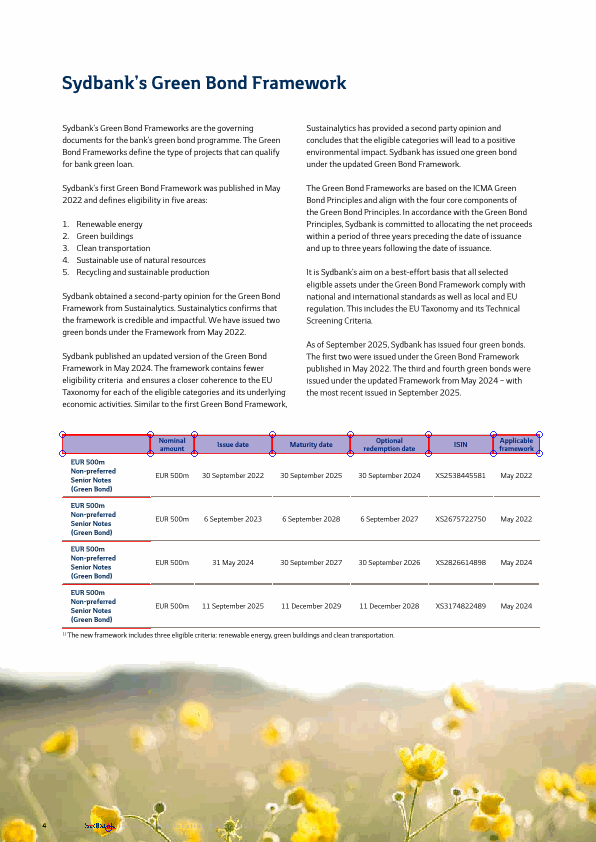

In [40]:
im = fourth_page.to_image()
im.debug_tablefinder()

In [45]:
# Classify subset of sentences.
# The padding and trunctuation parameters help us with classifying texts of different length.
sub_sentences_sb_gb_ia = sentences_sb_gb_ia[60:67] # takes around 20 seconds
env_sb_gb_ia = pipe_env(sentences_sb_gb_ia, padding=True, truncation=True)

# You might only want the labels.
env_labels_sb_gb_ia = [x["label"] for x in env_sb_gb_ia]

In [46]:
# Let's look at the results. We use a dataframe for this purpose.
data_env_sb_gb_ia = pd.DataFrame({"sentence": sentences_sb_gb_ia, "environmental": env_labels_sb_gb_ia})
# Which sentences are labeled as environmental?
data_env_sb_gb_ia[data_env_sb_gb_ia["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Click the first blue symbol in the top right of the dataframe to have a closer look.

,sentence,environmental
1,The climate crisis continues to shape our glob...,environmental
2,"Once again, we are witnessing concerning envir...",environmental
3,The insurance industry is reporting unpreceden...,environmental
4,The scale and frequency of extreme weather eve...,environmental
5,"At the same time, continued growth in global i...",environmental
...,...,...
130,The Committee also conducts general risk asses...,environmental
132,At Sydbank our aim is to support sustainable b...,environmental
133,Proceeds from the green bond issuance can ther...,environmental
136,The bulk of the use of proceeds is allocated t...,environmental


In [47]:
data_env_sb_gb_ia['environmental'].unique()

<StringArray>
['none', 'environmental']
Length: 2, dtype: str

               sentence
environmental          
environmental       106
none                 48


<Axes: xlabel='environmental'>

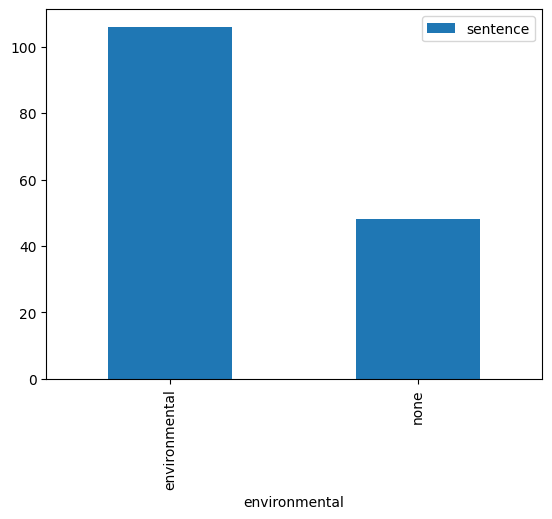

In [48]:
# It could also be interesting to look at the proporation of environmental sentences.
print(data_env_sb_gb_ia.groupby("environmental").count())
data_env_sb_gb_ia.groupby("environmental").count().plot(kind="bar")

In [53]:
# To load the model, we use the exact same steps as above.
model_name = "climatebert/distilroberta-base-climate-sentiment"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name, max_len=512)
pipe_sent = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [50]:
# Use the model on the dataset.
sentiment_sb_gb_ia = pipe_sent(sentences_sb_gb_ia, padding=True, truncation=True)
# Add the sentiment to the DataFrame.
data_env_sb_gb_ia["sentiment"] = [x["label"] for x in sentiment_sb_gb_ia]

In [51]:
# Again, have a look at the outcome.
data_env_sb_gb_ia[data_env_sb_gb_ia["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Audi seems to display a enthusiastic, pironeering spirit towards sustainability. This positive attitude is reflected as "opportunity".

,sentence,environmental,sentiment
1,The climate crisis continues to shape our glob...,environmental,risk
2,"Once again, we are witnessing concerning envir...",environmental,risk
3,The insurance industry is reporting unpreceden...,environmental,risk
4,The scale and frequency of extreme weather eve...,environmental,risk
5,"At the same time, continued growth in global i...",environmental,opportunity
...,...,...,...
130,The Committee also conducts general risk asses...,environmental,risk
132,At Sydbank our aim is to support sustainable b...,environmental,opportunity
133,Proceeds from the green bond issuance can ther...,environmental,opportunity
136,The bulk of the use of proceeds is allocated t...,environmental,opportunity


sentiment
neutral        42
opportunity    58
risk            6
Name: environmental, dtype: int64


<Axes: xlabel='sentiment'>

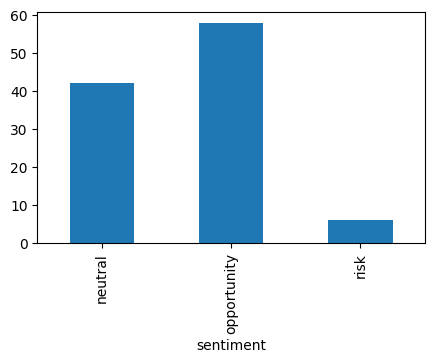

In [52]:
# Let's plot the distribution again.
print(data_env_sb_gb_ia[data_env_sb_gb_ia["environmental"] == "environmental"].groupby("sentiment").count()["environmental"])
data_env_sb_gb_ia[data_env_sb_gb_ia["environmental"] == "environmental"].groupby("sentiment").count()["environmental"].plot(kind = "bar", figsize=(5, 3))